# Success Rate Evaluation for Side-Channel Attacks

This notebook is organized in two main phases:

- **Online phase (optional)** – Power traces are acquired directly from the CW305 board while it performs AES encryptions. This phase can be skipped if a pre-recorded trace set is already available.
- **Offline phase** – Given a set of traces and the corresponding plaintext/ciphertext, a Correlation Power Analysis (CPA) attack is run to evaluate how many traces are needed to reliably recover the secret key.

The core metric we use is the **success rate (SR)**.
The success rate is a key metric in side-channel evaluation because it directly measures **how many traces an attacker needs to recover the full secret key with high probability**. Unlike looking only at correlation peaks or signal-to-noise ratios, SR captures both the effectiveness of the leakage model and the practical effort required for a successful attack. In this notebook, we will compute and visualize SR as the number of traces grows, providing a clear picture of the security level of the target implementation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import serial.tools.list_ports as port_list
import sys

sys.path.append( '../../../ciphers/AES_python' )
sys.path.append( '../../../sca_python' )

# Set the S-Box to test
tested_sbox = "sbox_freyre_2"
sbox_id = tested_sbox.replace("sbox_", "")

In [2]:
# If capure is set to True, the script will capture data from the PicoScope
capture = True
# If save_dataset is set to True, the script will save the captured data to a .dat file
save_dataset = True

In [3]:
sys.path.append('../../../sca_python/utils')
from dat_tracereader import dat_tracereader

# Configuration parameters
pt_len = 16  # size of the plaintext in bytes
ct_len = 16  # size of the ciphertext in bytes
key_len = 16  # size of the key in bytes
n_trc = 5000  # number of traces to capture or read from dataset
    
if not capture:
    try:
        reader = dat_tracereader()
        reader.open_ro("../../dataset/aes_"+sbox_id+".dat")
        trace, key, plaintext, ciphertext =  reader.read_traces(n_trc)
        num_samples = trace.shape[1]  # number of samples per trace
        reader.close()
    except Exception as e:
        print("Error loading dataset: ", e)
else: 
    # Allocate memory for traces and data
    num_samples = 1612
    trace = np.empty((n_trc, num_samples), dtype=np.float64)  
    plaintext = np.empty((n_trc, pt_len), dtype=np.uint8)  
    ciphertext = np.empty((n_trc, ct_len), dtype=np.uint8)  
    key = np.empty(key_len, dtype=np.uint8) 

## Optional online phase : AES power traces capture

### Picoscope and CW305 initialization and capture of power traces

In [ ]:
from tqdm.notebook import tnrange
import chipwhisperer as cw
from Crypto.Cipher import AES
from pico_api import PS5000aWrapper
from CW305_api import CW305Wrapper
from AES_golden import AES_golden_model
from analyzer.utils.sca_plots import sca_plot
import time

if capture:
    # Set the bitstream file path based on the S-Box
    bitstream = r"../../../../hw/fpga/bitstream/aes/aes_single_round/cw305_top_"+sbox_id+"_lut.bit"

        # Load the bitstream on the CW305 board and initialize the PicoScope
    try:
        # Initialize picoscope
        ps = PS5000aWrapper()
        ps.get_unitInfo()
        ps.scope_setup()
        num_samples = ps.nSamples
        # Initialize CW305
        cw305 = CW305Wrapper(ps, bitstream)
    except ModuleNotFoundError as e:
        print(e)
    
    # Initialize key,text pair generator
    ktp = cw.ktp.Basic()
    key, plaintext[0] = ktp.next()

    # Initialize the AES software emulated cipher
    cipher = AES_golden_model()

    # Each element of the key is converted to a 2-digit hex string 
    formatted_key = ''.join(format(el, '02x') for el in key)
    print("Key: ", [ hex(subkey) for subkey in key])

    # Write the key to the CW305
    cw305.set_key(key)

    # Dummy capture call due to bug of using AC coupling
    cw305.capture_trace(plaintext[0])

    for i in tnrange(n_trc, desc='Capturing traces'):
        ciphertext[i], trace[i] = cw305.capture_trace(plaintext[i])
        # Sanity check with expected ciphertext
        formatted_pt = (format(el, '02x') for el in plaintext[i])
        text = [int(subbyte, 16) for subbyte in formatted_pt]
        assert (list(ciphertext[i]) == list(cipher.encrypt(formatted_key, text, tested_sbox))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(list(ciphertext[i]), list(plaintext[i]))
        if (i < n_trc-1):
            _ , plaintext[i+1] = ktp.next() 

    # Disconnect CW305 and picoscope
    cw305.dis()
    ps.dis()

    # If save_dataset is set to True, the attack data are stored to a .dat file
    if (save_dataset):
        try:
            writer = dat_tracereader()
            key = np.array(key, dtype=np.uint8)
            writer.create(
                pathname="traceset/aes_"+sbox_id+".dat",
                trace_len=int(num_samples),
                sample_type='d',
                key_len=key_len,
                plaintext_len=pt_len,
                ciphertext_len=ct_len
            )
            writer.write_traces(trace, key, plaintext, ciphertext)
            print("Traces written:", writer.num_traces)
            writer.close()
        except Exception as e:
            print("Error saving dataset: ", e)

Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.10.5074
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : 11768/0019
CalDate                       : 24Feb25
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0


(ChipWhisperer Target WARNING|File CW305.py:345) Verilog defines not found in default location (/home/mattia-mirigaldi/.pyenv/versions/cw/lib/python3.9/site-packages/chipwhisperer/../../hardware/victims/cw305_artixtarget/fpga/common/cw305_defines.v).
Using defines from CW305.py.If this isn't what you want, either add 'slurp=False', or provide defines location in 'defines_files'


True
Key:  ['0x2b', '0x7e', '0x15', '0x16', '0x28', '0xae', '0xd2', '0xa6', '0xab', '0xf7', '0x15', '0x88', '0x9', '0xcf', '0x4f', '0x3c']


Capturing traces:   0%|          | 0/5000 [00:00<?, ?it/s]

Error saving dataset:  [Errno 2] No such file or directory: 'dataset/aes_freyre_2.dat'


### Sanity check : plotting power traces captured (40 samples overlapped)

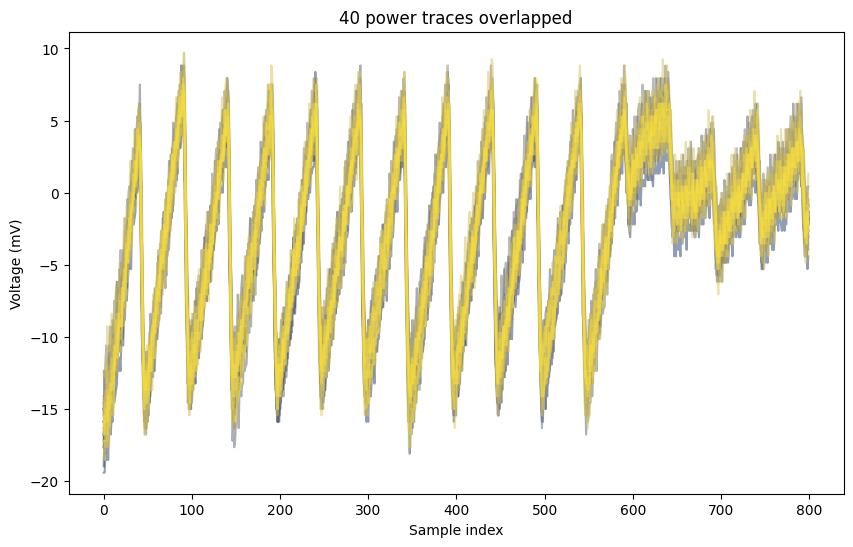

<Figure size 640x480 with 0 Axes>

In [ ]:
sca_plt = sca_plot()
power_plt = sca_plt.power_traces_overlapped(traces=list(trace), finish=800)
power_plt.show()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
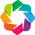

In [ ]:
import os
import chipwhisperer.analyzer as cwa
import chipwhisperer as cw
import holoviews as hv
hv.extension('bokeh')
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels
from analyzer.attack.aes.key_schedule import key_schedule_rounds

## Offline phase : Success rate computation

To calculate the success rate, an incremental number of traces is used.
The total set of traces is split into groups with an incremental size (e.g., first 500 traces, then 1000, 1500, …). 

For each group:

1. A CPA attack is executed.
2. The tool returns the *guessed* key bytes.
3. For each key byte `i`, we define:

   SR[i] =
   \begin{cases}
   1 & \text{if guessed\_key\_byte}_i = \text{correct\_key\_byte}_i \\
   0 & \text{otherwise}
   \end{cases}


4. The **global success rate** for AES-128 is then:

   $$SR = \frac{1}{16} \sum_{i=0}^{15} SR[i]$$
    

ChipWhisperer Analyzer supports a callback mechanism that is invoked periodically during the attack (controlled by a `resolution` parameter, e.g., every 25 traces). 
This callback is used to update SR as more traces are processed, effectively slicing the trace set and building the SR-versus-number-of-traces curve.

In [ ]:
# The resolution defines how many traces are added each time to evaluate the n-success_rate.
resolution = 25

# The maximum number of iterations for the attack loop
max_iterations = 1

In [ ]:
def success_rate_callback():
    global success_rate
    global key

    # Get the attack results (guessed key bytes).
    # The "find_maximums" method returns 3 nested lists:
    # 1. The first list contains the guessed key bytes ordered by subkey index
    #    [subkey0_data, subkey1_data, subkey2_data, ...]
    # 2. subkey0_data is another list containing guesses ordered by strength of correlation:
    #    [guess0, guess1, guess2, ...]
    # 3. guess0 is a tuple containing:
    #    (key_guess, location_of_max, correlation)
    # So, with the syntax kguess[0][0], we get the best key guess for each subkey.
    results = attack.results
    guessed_key = [kguess[0][0] for kguess in results.find_maximums()]
    
    iteration_success_rate = []
    # Compare the guessed key bytes with the correct key bytes
    for key_byte, guessed_key_byte in zip(key, guessed_key):
        # If the guessed key byte matches the correct key byte, i-th success_rate is 1, otherwise 0
        success_rate_i = 1 if key_byte == guessed_key_byte else 0
        iteration_success_rate.append(success_rate_i)

    # Calculate the average success rate for the current iteration
    avg_success_rate = sum(iteration_success_rate) / len(iteration_success_rate)
    # Append the average success rate to the success_rate list
    success_rate.append(avg_success_rate)

In [ ]:
print("Analyzing traces (this might take a while)...")
# Performance metrics
tic = time.perf_counter()
# Initialize the success rate list
success_rate = []

# Attack loop
for iteration in range(1,max_iterations+1):
    project_file = "../../build/xheep_test/xheep_CW305_AES_success_rate_" + sbox_id + "_iteration_" + str(iteration) + ".cwp"
    project = cw.open_project(project_file)

    # The Hamming Weight is used as the leakage model for the CPA attack.
    leak_model = AES128SboxResistantLeakageModels().FirstRound_ModifiedSbox_Output(tested_sbox)
    attack = cwa.cpa(project, leak_model)
    
    # Perform the CPA attack
    attack.run(success_rate_callback, resolution)

    project.close()


# Success Rate plot with matplotlib
print("Generating success rate plot...")

xrange = [i * resolution for i in range(len(success_rate))]
# xrange = range(len(success_rate))
plt.figure(figsize=(10, 5))
plt.plot(xrange, success_rate, color="red")
plt.xlabel("Number of traces")
plt.ylabel("Success Rate")
plt.title("AES CPA Success Rate")
plt.grid(True)
plt.savefig("../x-heep/Graphs/AES_c/AES_cpa_success_rate_" + sbox_id + ".png", dpi=300)
# plt.show()


toc = time.perf_counter()
print(f"[LOG] OFFLINE PHASE: Computation completed in {(toc - tic)/60:0.2f} minutes.")
